In [ ]:
!pip install snowflake-connector-python pandas scikit-learn

In [ ]:
import pandas as pd
import snowflake.connector
conn=snowflake.connector.connect(
    user='prakalya',
    password='xxxxxxxxxxxxxx',
    account='xxxxxxxxxxx',
    database='xxxxx',
    schema='public',
    warehouse='COMPUTE_WH'
)
query='SELECT * from "iris"';

In [ ]:
query='SELECT * FROM IRIS'
d=pd.read_sql(query,conn)
conn.close()
print(d.head())

/tmp/ipykernel_4202/2086360530.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  d=pd.read_sql(query,conn)


   ID  SEPALLENGTHCM  SEPALWIDTHCM  PETALLENGTHCM  PETALWIDTHCM      SPECIES
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
d.shape

(150, 6)

In [ ]:
d.describe()

,ID,SEPALLENGTHCM,SEPALWIDTHCM,PETALLENGTHCM,PETALWIDTHCM
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             150 non-null    int64  
 1   SEPALLENGTHCM  150 non-null    float64
 2   SEPALWIDTHCM   150 non-null    float64
 3   PETALLENGTHCM  150 non-null    float64
 4   PETALWIDTHCM   150 non-null    float64
 5   SPECIES        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
d.isnull().sum()

,0
ID,0
SEPALLENGTHCM,0
SEPALWIDTHCM,0
PETALLENGTHCM,0
PETALWIDTHCM,0
SPECIES,0


In [ ]:
#Categorical encoding
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
d['SPECIES']=l.fit_transform(d['SPECIES'])
d

,ID,SEPALLENGTHCM,SEPALWIDTHCM,PETALLENGTHCM,PETALWIDTHCM,SPECIES
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


                     ID  SEPALLENGTHCM  SEPALWIDTHCM  PETALLENGTHCM  \
ID             1.000000       0.716676     -0.397729       0.882747   
SEPALLENGTHCM  0.716676       1.000000     -0.109369       0.871754   
SEPALWIDTHCM  -0.397729      -0.109369      1.000000      -0.420516   
PETALLENGTHCM  0.882747       0.871754     -0.420516       1.000000   
PETALWIDTHCM   0.899759       0.817954     -0.356544       0.962757   
SPECIES        0.942830       0.782561     -0.419446       0.949043   

               PETALWIDTHCM   SPECIES  
ID                 0.899759  0.942830  
SEPALLENGTHCM      0.817954  0.782561  
SEPALWIDTHCM      -0.356544 -0.419446  
PETALLENGTHCM      0.962757  0.949043  
PETALWIDTHCM       1.000000  0.956464  
SPECIES            0.956464  1.000000  


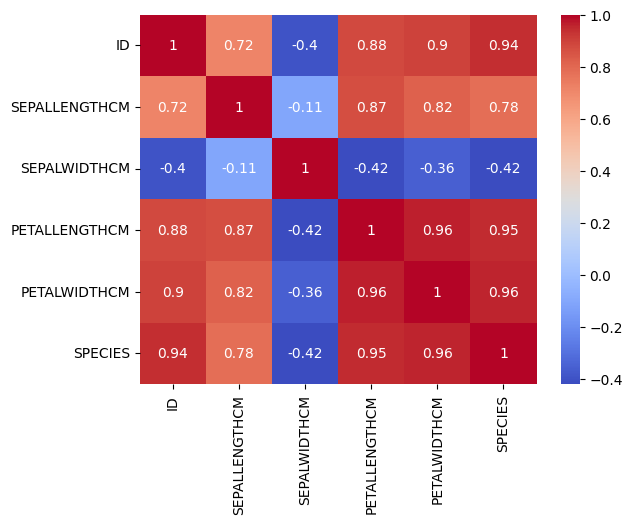

In [ ]:
#Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix=d.corr(numeric_only=True)
print(correlation_matrix)
sns.heatmap(correlation_matrix,cmap='coolwarm',annot=True)
plt.show()

In [ ]:
x=d[["SEPALLENGTHCM","PETALLENGTHCM","SEPALWIDTHCM","PETALWIDTHCM"]]
y=d[["SPECIES"]]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier(criterion='entropy',max_depth=3)
clf=clf.fit(x_train,y_train)

In [ ]:
#predicting
y_predict=clf.predict(x_test)

In [ ]:
#Evaluatin metrics
from sklearn.metrics import accuracy_score
print("Accuracy score: ",accuracy_score(y_test,y_predict))

Accuracy score:  1.0


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_predict)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
from sklearn.metrics import classification_report
cr=classification_report(y_test,y_predict)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



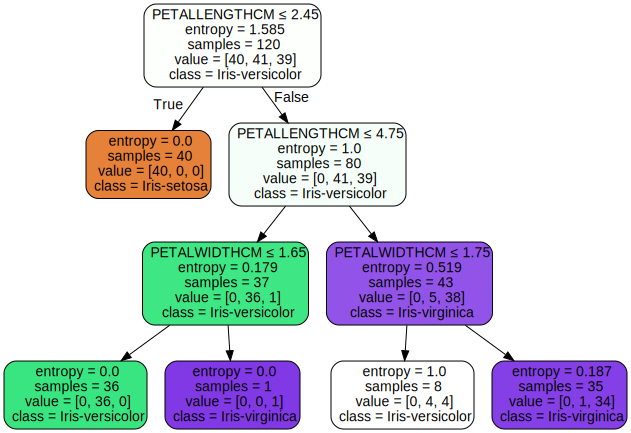

In [ ]:
#tree visualization
import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(
    clf,
    out_file=None,
    feature_names=x.columns,
    class_names=l.classes_,
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph